# 1.	Construya el diagrama de dispersión correspondiente. Incluya título, nombres de los ejes y unidades de medida.

In [ ]:
#Cargo codigo R en GCP (google colab enterprise)
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
#cargar el archivo desde GCS a la máquina virtual
%%R
system("gsutil cp 'gs://all-in-master/MÉTODOS ESTADÍSTICOS PARA LA CIENCIA DE DATOS/DATA_CONFECCIONES.csv' /tmp/DATA_CONFECCIONES.csv")

#leer el archivo
DATA_CONFECCIONES <- read.csv("/tmp/DATA_CONFECCIONES.csv")

In [ ]:
#mostrar los primeros registros
%%R
head(DATA_CONFECCIONES)

  Semana Horas Produccion Defectos Costo Venta
1      1   312        966      6.8 16530   592
2      2   328        970      4.1 17210   701
3      3   305        964      8.5 15360   482
4      4   340       1015      5.7 16490   674
5      5   355       1078      3.6 18940   853
6      6   318        935      9.2 14020   407


In [ ]:
#ver todas las variables en el archivo
%%R
names(DATA_CONFECCIONES)

[1] "Semana"     "Horas"      "Produccion" "Defectos"   "Costo"     
[6] "Venta"     


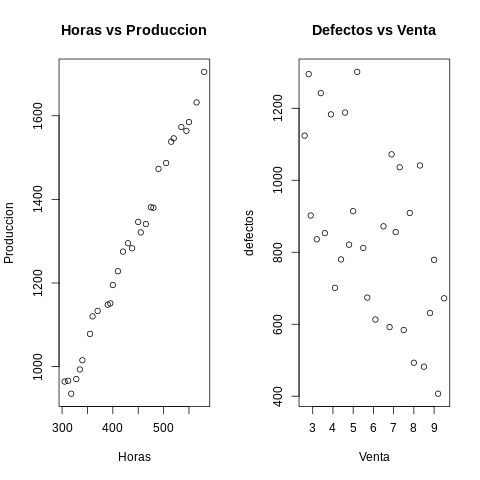

In [ ]:
%%R
#dividir pantalla
par(mfrow = c(1, 2))

#primer grafico para buscar relacion entre horas vs produccion
plot(x = DATA_CONFECCIONES$Horas, DATA_CONFECCIONES$Produccion,
     main = "Horas vs Produccion", xlab = "Horas", ylab = "Produccion")

#segundo grafico para buscar relacion entre defectos y Venta
plot(x = DATA_CONFECCIONES$Defectos, DATA_CONFECCIONES$Venta,
     main = "Defectos vs Venta", xlab = "Venta", ylab = "defectos")


como se esperaba hay relacion entre horas vs produccion pero hay relacion entre defectos vs ventas clara.

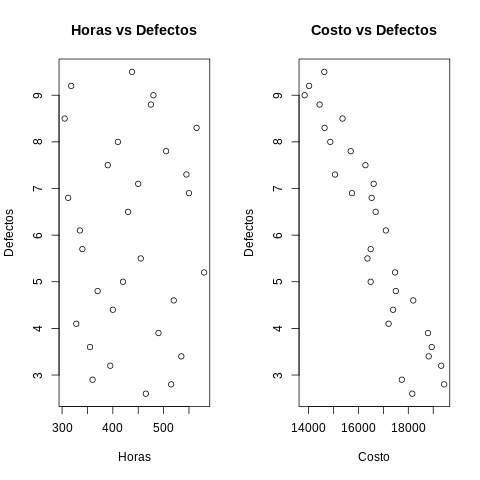

In [ ]:
%%R

#dividir pantalla
par(mfrow = c(1, 2))

#tercer grafico para buscar relacion entre horas vs produccion
plot(x = DATA_CONFECCIONES$Horas, DATA_CONFECCIONES$Defectos,
     main = "Horas vs Defectos", xlab = "Horas", ylab = "Defectos")

#cuarto grafico para buscar relacion entre defectos y Venta
plot(x = DATA_CONFECCIONES$Costo, DATA_CONFECCIONES$Defectos,
     main = "Costo vs Defectos", xlab = "Costo", ylab = "Defectos")

al parecer en el diagrama de dispercion horas vs defectos, no parece haber una relacion fuerte en entre las variables, sin embargo, hay una una relacion entre el costo costo promedio de la materia prima y los defectos, al parecer, entre mas alto el gasto en materia prima, menos defectuosos seran las confecciones.

# 2) Calcule el coeficiente de correlación de Pearson e interprete su signo y magnitud en el contexto del caso.


- Como se habia mencionado arriba, **Horas vs Produccion** tienen una fuerte relacion, es decir, ambas se mueven a la misma relacion.

- Para **Defectos vs Venta**, se observa una relacion moderada, sin embargo es una relacion de direccion opuesta entre las dos variables.

- Por otro lado, **Horas vs Defectos** se puede apreciar una relacion muy debil o nula practicamente.

- Finalmente, **Costo vs Defecto** la relacion es fuerte, ambas variables se mueven en direcciones opuestas, en otras palabras son son inversamente proporcioal.

In [ ]:
%%R
# Calcular el coeficiente de correlación de Pearson
coef_pearson_para_Horas_vs_Produccion <- cor(DATA_CONFECCIONES$Horas, DATA_CONFECCIONES$Produccion, method = "pearson")
coef_pearson_para_Defectos_vs_Venta <- cor(DATA_CONFECCIONES$Defectos, DATA_CONFECCIONES$Venta, method = "pearson")
coef_pearson_para_Horas_vs_Defectos <- cor(DATA_CONFECCIONES$Horas, DATA_CONFECCIONES$Defectos, method = "pearson")
coef_pearson_para_Costo_vs_Defecto <- cor(DATA_CONFECCIONES$Costo, DATA_CONFECCIONES$Defectos, method = "pearson")

# Imprimir el resultado
print(paste("Horas vs Produccion = ", coef_pearson_para_Horas_vs_Produccion))
print(paste("Defectos vs Venta = ", coef_pearson_para_Defectos_vs_Venta))
print(paste("Horas vs Defectos = ", coef_pearson_para_Horas_vs_Defectos))
print(paste("Costo vs Defecto = ", coef_pearson_para_Costo_vs_Defecto))

[1] "Horas vs Produccion =  0.99489883737941"
[1] "Defectos vs Venta =  -0.566857895133719"
[1] "Horas vs Defectos =  -0.00857588714089995"
[1] "Costo vs Defecto =  -0.932755218941997"


#3 Ajuste un modelo de regresión lineal simple de la forma: y ̂  = bx+a.

In [ ]:
%%R
#ajustar el modelo
modelo_lineal <- lm(Produccion ~ Horas, data = DATA_CONFECCIONES)

#mostrar los coeficientes
coef(modelo_lineal)

(Intercept)       Horas 
  94.548108    2.745057 


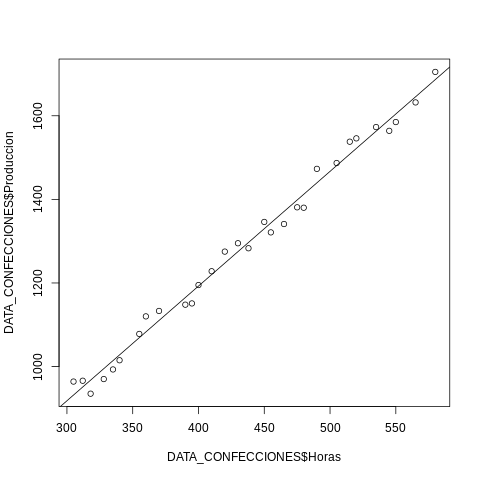

In [ ]:
%%R
#grafica del modelo
plot(x = DATA_CONFECCIONES$Horas, y = DATA_CONFECCIONES$Produccion,)

# 2. Dibujar la línea del modelo de regresión
abline(modelo_lineal)

# 4.	Interprete la pendiente y el intercepto en términos de la relación analizada.

Esto quiere decir que por cada hora mas trabajada, la fabrica produce 2.745057 mas prendas.
por otro lado si la hora fuese 0, la fabrica empezaria con 94.548108, esto podria ser debido a prendas que no estan terminadas del dia anterior.

# 5.	Valide el modelo con ANOVA para regresión lineal simple.

In [53]:
%%R
#validacion del modelo con anova
anova(modelo_lineal)

Analysis of Variance Table

Response: Produccion
          Df  Sum Sq Mean Sq F value    Pr(>F)    
Horas      1 1492897 1492897  2723.5 < 2.2e-16 ***
Residuals 28   15348     548                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Para el modelo de regresion lineal simple se obtuvo un estadistico F de **2723.5** y un p-valor **2.2e-16**. Dado que el p-valor es menor al nivel de significancia del 5%, se rechaza la hipotesis de que el modelo no tiene capacidad explicativa. En ese orden de ideas, el modelo queda validado y demostrado.
La variable Hora explica de manera significativa la variabilidad observada en la Produccion.

# 6.	Use alfa = 5% para decidir si la relación es estadísticamente significativa.

In [ ]:
%%R
#resumen del modelo
summary(modelo_lineal)


Call:
lm(formula = Produccion ~ Horas, data = DATA_CONFECCIONES)

Residuals:
    Min      1Q  Median      3Q     Max 
-32.476 -20.689   4.314  19.638  37.232 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  94.5481    23.2529   4.066 0.000352 ***
Horas         2.7451     0.0526  52.187  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 23.41 on 28 degrees of freedom
Multiple R-squared:  0.9898,	Adjusted R-squared:  0.9895 
F-statistic:  2723 on 1 and 28 DF,  p-value: < 2.2e-16



Es matematicamente seguro que entre mas horas trabaajdas, mayor sera la produccion y la probabilidad de que esto sea coinscidencia es cero.

# 5. Reporte e interprete el valor de R^2 acompañado de la conclusión del modelo.

Dado que el coeficiente de determinación obtenido por el modelo es de 0.9898, se explica la variabilidad en el volumen de producción directamente por la cantidad de horas trabajadas, y solo un 1.02% de la variación en la producción depende de otros factores.
En conclusión, el modelo de regresión lineal es altamente efectivo y logra predecir con una significación estadística contundente y excelente poder explicativo. El modelo presentado demuestra que las horas de trabajo son el motor exclusivo del volumen de producción.
Con esto, la gerencia y las partes interesadas pueden planificar turnos, proyectar inventarios y estimar rendimientos a futuro con un margen de error mínimo.